In [13]:
# ============ #
# 1. LIBRERÍAS #
# ============ #

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import mean_absolute_percentage_error


In [14]:
# =================== #
# 2. LECTURA DE RUTAS #
# =================== #

mainpath = os.path.join(os.getcwd(), "..", "..", "data", "raw")
filename = "job_salary_prediction_dataset.csv"
fullpath = os.path.join(mainpath, filename)


In [15]:
# ================= #
# 3. CARGA DE DATOS #
# ================= #

df = pd.read_csv(fullpath, sep=",")
pd.set_option('display.max_columns', None)


In [16]:
# ============================== #
# 4. IDENTIFICACIÓN DE VARIABLES #
# ============================== #

def variables(df = df):
    float_cols = df.select_dtypes(include='float64').columns.tolist()
    int_cols = df.select_dtypes(include='int64').columns.tolist()
    cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
    target = 'salary'
    features = [col for col in float_cols + int_cols if col != target]
    return features, target, cat_cols

features, target, cat_cols = variables()


In [17]:
# ================ #
# 5. PREPROCESADOR #
# ================ #

preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols),
    ('num', 'passthrough', features)
])


In [18]:
# =============================== #
# VISUALIZAR EL PRE-PROCESAMIENTO #
# =============================== #

preprocessor


ColumnTransformer(transformers=[('cat',
                                 OneHotEncoder(drop='first',
                                               handle_unknown='ignore'),
                                 ['job_title', 'education_level', 'industry',
                                  'company_size', 'location', 'remote_work']),
                                ('num', 'passthrough',
                                 ['experience_years', 'skills_count',
                                  'certifications'])])

In [19]:
# ========================= #
# 6. PARTICIÓN TRAIN / TEST #
# ========================= #

X = df[features + cat_cols]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)


In [20]:
# ===================== #
# 7. MODELO ÁRBOL DE DECISIÓN #
# ===================== #

model = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('regressor', DecisionTreeRegressor(random_state=42))
])

model.fit(X_train, y_train)


Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['job_title',
                                                   'education_level',
                                                   'industry', 'company_size',
                                                   'location', 'remote_work']),
                                                 ('num', 'passthrough',
                                                  ['experience_years',
                                                   'skills_count',
                                                   'certifications'])])),
                ('regressor', DecisionTreeRegressor(random_state=42))])

In [21]:
# ============== #
# 8. EVALUACIÓN  #
# ============== #

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("MAPE:", mape)
print("MAPE(%):", mape * 100)
print("R2:", r2)


MAE: 8132.36766
RMSE: 10668.430483575205
MAPE: 0.05809040682036137
MAPE(%): 5.809040682036137
R2: 0.9183277547560325


In [22]:
# ======================================== #
# 8.1. DATAFRAME CON RESULTADOS Y ERRORES  #
# ======================================== #

X_test_df = pd.DataFrame(X_test).reset_index(drop=True)
y_test_df = pd.Series(y_test).reset_index(drop=True)
y_pred_df = pd.Series(y_pred)

df_resultados = X_test_df.copy()
df_resultados["y_real"] = y_test_df
df_resultados["y_pred"] = y_pred_df
df_resultados["error"] = df_resultados["y_real"] - df_resultados["y_pred"]
df_resultados["abs_error"] = df_resultados["error"].abs()

df_resultados.sample(20)


,experience_years,skills_count,certifications,job_title,education_level,industry,company_size,location,remote_work,y_real,y_pred,error,abs_error
5391,18,7,2,Business Analyst,High School,Consulting,Startup,Sweden,Hybrid,99220,99528.0,-308.0,308.0
60552,10,6,2,Data Scientist,PhD,Healthcare,Startup,Australia,Hybrid,131043,135053.0,-4010.0,4010.0
32733,0,14,2,Backend Developer,Diploma,Consulting,Startup,Singapore,No,80912,83045.0,-2133.0,2133.0
57410,8,6,0,Machine Learning Engineer,High School,Media,Large,Remote,Hybrid,138426,132051.0,6375.0,6375.0
43392,16,2,4,Backend Developer,Bachelor,Media,Startup,Remote,Hybrid,116084,122642.0,-6558.0,6558.0
3967,3,1,3,Backend Developer,PhD,Finance,Startup,Remote,Yes,113521,121530.0,-8009.0,8009.0
36145,10,8,3,Product Manager,Diploma,Government,Medium,Remote,Yes,141883,137679.0,4204.0,4204.0
42206,20,4,3,Data Scientist,Diploma,Telecom,Startup,Singapore,Yes,138112,130421.0,7691.0,7691.0
41991,2,9,5,AI Engineer,High School,Manufacturing,Medium,Netherlands,Yes,128548,117573.0,10975.0,10975.0
1554,16,5,0,Product Manager,Diploma,Telecom,Enterprise,Canada,Yes,212872,218775.0,-5903.0,5903.0


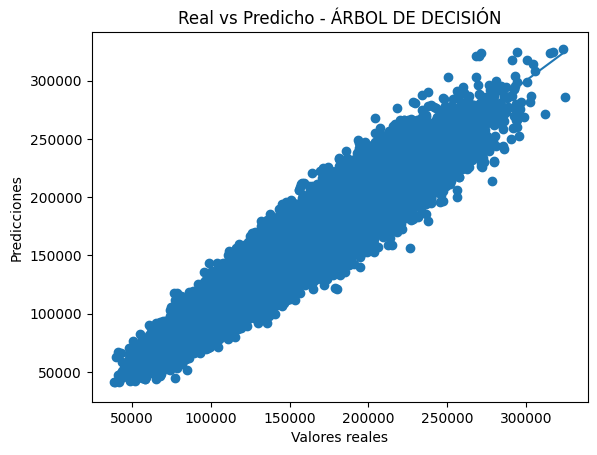

In [23]:
# ====================== #
# 8.2. REAL VS PREDICHO  #
# ====================== #

plt.scatter(df_resultados["y_real"], df_resultados["y_pred"])
plt.xlabel("Valores reales")
plt.ylabel("Predicciones")
plt.title("Real vs Predicho - ÁRBOL DE DECISIÓN")
plt.plot(
    [df_resultados["y_real"].min(), df_resultados["y_real"].max()],
    [df_resultados["y_real"].min(), df_resultados["y_real"].max()]
)
plt.show()


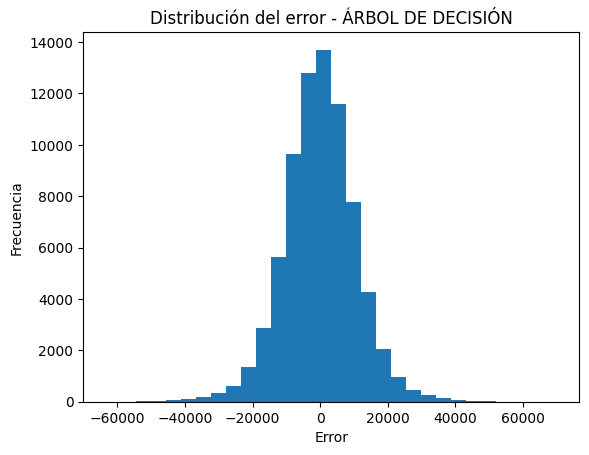

In [24]:
# ============================= #
# 8.3. DISTRIBUCIÓN DE ERRORES  #
# ============================= #

plt.hist(df_resultados["error"], bins=30)
plt.title("Distribución del error - ÁRBOL DE DECISIÓN")
plt.xlabel("Error")
plt.ylabel("Frecuencia")
plt.show()
